# The kT-bit — single-pair lesson

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/knowm/ktram-neural-core/blob/main/python/examples/kt-bit/kt_bit.ipynb)

The runnable companion to *Chapter 3b: The kT-bit Up Close*. Everything here runs on one
kT-bit — the smallest lane: one address space, one differential pair, one device per side,
selected by the fixed AAT `z = (0,)`.

The point of the seeds is that you can change them. Change `init`, `level`, `model`,
`seed`, and the step count and watch the two numbers — the weight `w` and the magnitude
`m` — move.

## Setup

On Colab this installs the published package. Locally it is a no-op if already installed.

In [1]:
%pip install -q ktram-neural-core matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
from ktram_neural_core import Core, READ_NOISE

Z = (0,)  # the single-synapse AAT: address 0 in the one space

def single_synapse_core(model='float', init='medium', seed=1, read_noise=0.0, **kw):
    # The emulator ships with thermal read noise ON (read_noise = READ_NOISE) at room
    # temperature. The lessons below are about the deterministic *state* (w and m read back
    # from the conductances), so we pass read_noise=0 to show clean reads — exactly as the
    # article does. "The read is a sample" near the end turns the hiss back on.
    return Core(1, 1, spaces_per_lane=1, num_lanes=1,
                model=model, init=init, seed=seed, read_noise=read_noise, **kw)

def execute_n(core, read, feedback, n):
    """Repeat evaluate(read); evaluate(feedback) n times, recording Ga/Gb each step.
    feedback=None makes only the read call."""
    lane = core.lane(0)
    gas, gbs = [], []
    for _ in range(n):
        lane.evaluate(Z, read)
        if feedback is not None:
            lane.evaluate(Z, feedback)
        ga, gb = core.read_gab(0, Z)
        gas.append(ga); gbs.append(gb)
    return gas, gbs

# the two numbers a kT-bit carries
def w_of(gas, gbs): return [(a - b) / (a + b) for a, b in zip(gas, gbs)]  # weight
def m_of(gas, gbs): return [a + b for a, b in zip(gas, gbs)]              # magnitude

## The smallest possible lane

One read returns the weight, in `[-1, 1]`. `read_gab` peeks at the two conductances
behind it (debug only — the hardware does not expose them).

In [3]:
core = single_synapse_core('float', 'medium', seed=1)
lane = core.lane(0)

y = lane.evaluate(Z, 'FF')          # forward read -> the weight
ga, gb = core.read_gab(0, Z)
print(f'y = {y:+.4f}')
print(f'Ga = {ga:.4f}  Gb = {gb:.4f}   ->   w = {(ga-gb)/(ga+gb):+.4f}')

y = -0.0225
Ga = 0.0518  Gb = 0.0542   ->   w = -0.0224


## A weight is two numbers

The weight `w = (Ga-Gb)/(Ga+Gb)` is what a read returns, and it is all a float stores.
The magnitude `m = Ga+Gb` is invisible to a single read: the **same** `w` sits at any
magnitude. `set_start_y(lane, z, y0, level)` sets the weight to `y0` and the magnitude
to `m = 2 * level * GMax`, so we can pin `w` and vary `m`.

In [4]:
for level in (0.05, 0.5):
    core = single_synapse_core('float', 'medium', seed=1)
    core.set_start_y(0, Z, y0=0.4, level=level)
    ga, gb = core.read_gab(0, Z)
    print(f'level={level:<4}  Ga={ga:.4f} Gb={gb:.4f}   '
          f'w={(ga-gb)/(ga+gb):+.3f}   m={ga+gb:.4f}')

level=0.05  Ga=0.0070 Gb=0.0030   w=+0.400   m=0.0100
level=0.5   Ga=0.0700 Gb=0.0300   w=+0.400   m=0.1000


## Property 1 — the magnitude is the weight's inertia

Two pairs, the **same** starting weight `w = 0.3` but different magnitude, driven with the
identical `(FF, RH)` feedback. The step in the weight is proportional to `1/m`, so the
low-magnitude pair races and the high-magnitude pair crawls. Try other `levels`, `y0`, `n`.

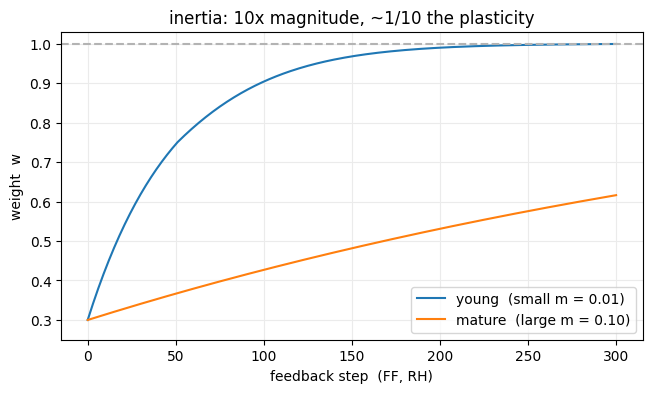

In [5]:
def inertia_run(level, n=300, y0=0.3, feedback='RH'):
    core = single_synapse_core('float', 'medium', seed=1)
    core.set_start_y(0, Z, y0=y0, level=level)
    gas, gbs = execute_n(core, 'FF', feedback, n)
    return [y0] + w_of(gas, gbs)   # prepend the matched start

plt.figure(figsize=(7.5, 4))
plt.plot(inertia_run(0.05), label='young  (small m = 0.01)')
plt.plot(inertia_run(0.5),  label='mature  (large m = 0.10)')
plt.axhline(1, color='0.7', ls='--'); plt.ylim(0.25, 1.03)
plt.xlabel('feedback step  (FF, RH)'); plt.ylabel('weight  w')
plt.title('inertia: 10x magnitude, ~1/10 the plasticity')
plt.legend(); plt.grid(color='0.92'); plt.show()

## Property 2 — the magnitude is a count of evidence

To *accumulate* evidence you grow the conductances, and that is what the **forward
feedbacks** do: `FH` adds a quantum to `Ga` (a "yes"), `FL` adds it to `Gb` (a "no").
Each is single-sided and additive — a literal tally, so the magnitude `m = Ga + Gb` is
the number of votes cast.

Read a Bernoulli(p) stream into a pair this way — `FFLV` to read without disturbing,
then `FH`/`FL` to vote — and the weight `w` tracks the running frequency and heads for
`2p - 1`. It holds until the conductances saturate; a bounded device can only count so
far.

(The **reverse feedbacks** `RH`/`RL` are the mirror — they *lower* one side, moving `w`
by depleting rather than accumulating, so `m` shrinks. More on that next.)

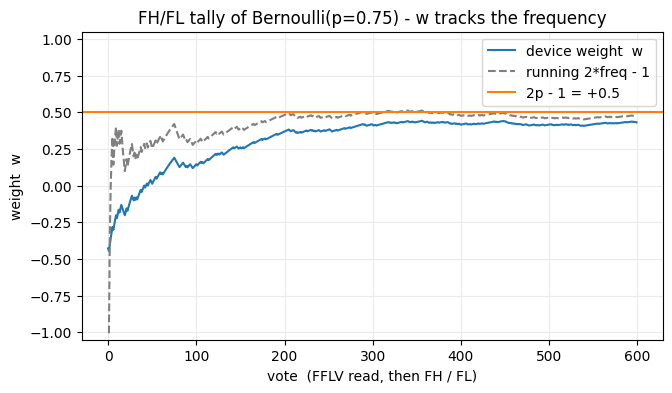

In [6]:
import random

p, N = 0.75, 600
rng = random.Random(0)
core = single_synapse_core('float', 'low', seed=1)   # weak prior, plastic
lane = core.lane(0)

w_dev, w_emp, ones = [], [], 0
for t in range(1, N + 1):
    lane.evaluate(Z, 'FFLV')                  # non-disturbing read
    x = 1 if rng.random() < p else 0
    lane.evaluate(Z, 'FH' if x else 'FL')     # FH = a 'yes' (Ga+), FL = a 'no' (Gb+)
    ones += x
    ga, gb = core.read_gab(0, Z)
    w_dev.append((ga - gb) / (ga + gb))
    w_emp.append(2 * ones / t - 1)            # running frequency, rescaled to [-1, 1]

plt.figure(figsize=(7.5, 4))
plt.plot(w_dev, color='tab:blue', label='device weight  w')
plt.plot(w_emp, color='0.5', ls='--', label='running 2*freq - 1')
plt.axhline(2 * p - 1, color='tab:orange', label=f'2p - 1 = {2*p-1:+.1f}')
plt.ylim(-1.05, 1.05); plt.xlabel('vote  (FFLV read, then FH / FL)')
plt.ylabel('weight  w')
plt.title(f'FH/FL tally of Bernoulli(p={p}) - w tracks the frequency')
plt.legend(); plt.grid(color='0.92'); plt.show()

### A pure count, or a moving average?

`FH`/`FL` accumulate, so they build a *cumulative* count — the all-time frequency — and
then saturate. Pair the reverse votes `RH`/`RL` with a full `FF` read instead and the
behavior changes: the `FF` read drives both conductances up while `RH`/`RL` bleed one
down, so the pair self-balances into a leaky integrator — an **exponential moving
average** that tracks a *changing* probability and never saturates. Flip `p` halfway
through and the weight follows.

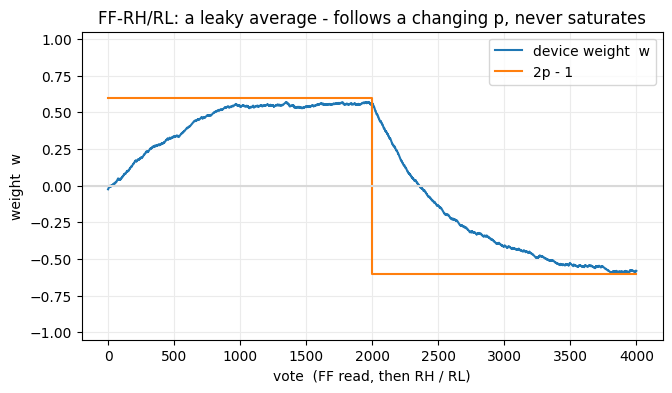

In [7]:
rng = random.Random(0)
core = single_synapse_core('float', 'medium', seed=1)
lane = core.lane(0)

w_dev = []
for t in range(4000):
    p = 0.8 if t < 2000 else 0.2               # the underlying probability flips halfway
    lane.evaluate(Z, 'FF')                      # full read - pushes both conductances up
    x = 1 if rng.random() < p else 0
    lane.evaluate(Z, 'RH' if x else 'RL')       # depleting vote
    ga, gb = core.read_gab(0, Z)
    w_dev.append((ga - gb) / (ga + gb))

plt.figure(figsize=(7.5, 4))
plt.plot(w_dev, color='tab:blue', label='device weight  w')
plt.step([0, 2000, 4000], [0.6, -0.6, -0.6], where='post',
         color='tab:orange', label='2p - 1')
plt.axhline(0, color='0.85'); plt.ylim(-1.05, 1.05)
plt.xlabel('vote  (FF read, then RH / RL)'); plt.ylabel('weight  w')
plt.title('FF-RH/RL: a leaky average - follows a changing p, never saturates')
plt.legend(); plt.grid(color='0.92'); plt.show()

### The read direction sets Hebbian vs anti-Hebbian

Even with no feedback, the read you repeat moves the pair, because a read still drives
the devices. `FF` is anti-Hebbian: it pushes both sides up, so `m` grows and the weight
`w` washes to zero. `RF` is Hebbian: it compounds the weight until the pair commits to a
rail.

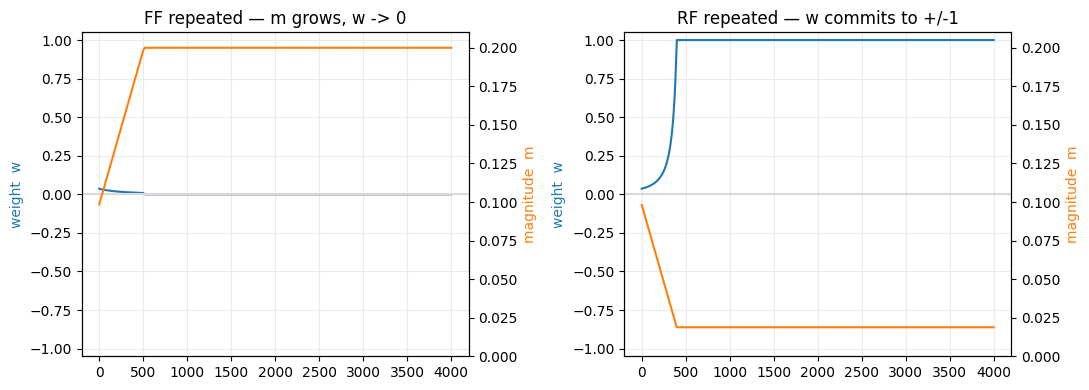

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, read, ttl in zip(axes, ('FF', 'RF'),
                         ('FF repeated — m grows, w -> 0',
                          'RF repeated — w commits to +/-1')):
    core = single_synapse_core('float', 'medium', seed=2)
    gas, gbs = execute_n(core, read, None, 4000)
    ax.plot(w_of(gas, gbs), color='tab:blue')
    ax.set_ylim(-1.05, 1.05); ax.axhline(0, color='0.85')
    ax.set_ylabel('weight  w', color='tab:blue'); ax.set_title(ttl)
    ax.grid(color='0.92')
    a2 = ax.twinx(); a2.plot(m_of(gas, gbs), color='tab:orange')
    a2.set_ylabel('magnitude  m', color='tab:orange'); a2.set_ylim(0, 0.21)
plt.tight_layout(); plt.show()

The five reverse-feedback instructions, from one shared start: `RH` up, `RL` down, `RU`
runs from zero, `RA` back to zero, `RZ` decays to zero.

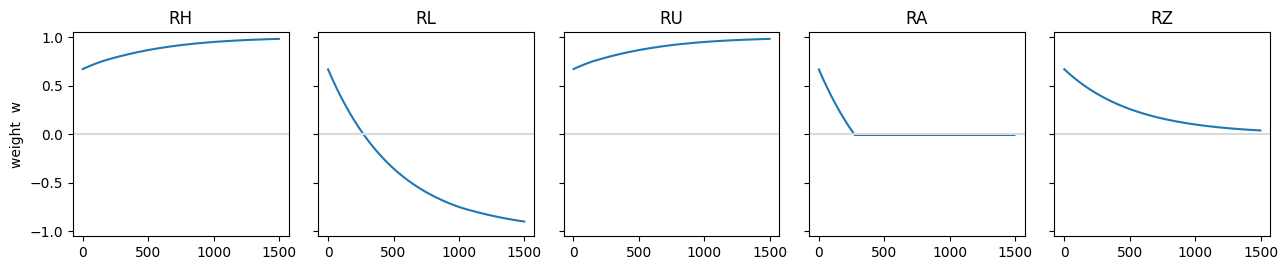

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(13, 2.8), sharey=True)
for ax, combo in zip(axes, ['RH', 'RL', 'RU', 'RA', 'RZ']):
    core = single_synapse_core('float', 'medium', seed=1)
    execute_n(core, 'FF', 'RH', 600)         # nudge to a clear positive start (w ~ 0.67)
    gas, gbs = execute_n(core, 'FF', combo, 1500)
    ax.plot(w_of(gas, gbs)); ax.set_ylim(-1.05, 1.05)
    ax.axhline(0, color='0.85'); ax.set_title(combo)
axes[0].set_ylabel('weight  w'); plt.tight_layout(); plt.show()

## Property 3 — the same drive on four devices

Everything so far ran on **Float**, infinitely fine. Change the model string and the
identical pulse — `(FF, RH)` up to a plateau, then `(FF, RL)` back down — runs on the
8-bit **Byte** (an integer staircase that tops out at the quantization ceiling) and on
**MSS** and **RS**, the real stochastic physics of a Knowm device. Same lesson on each; the model only sets resolution and noise.

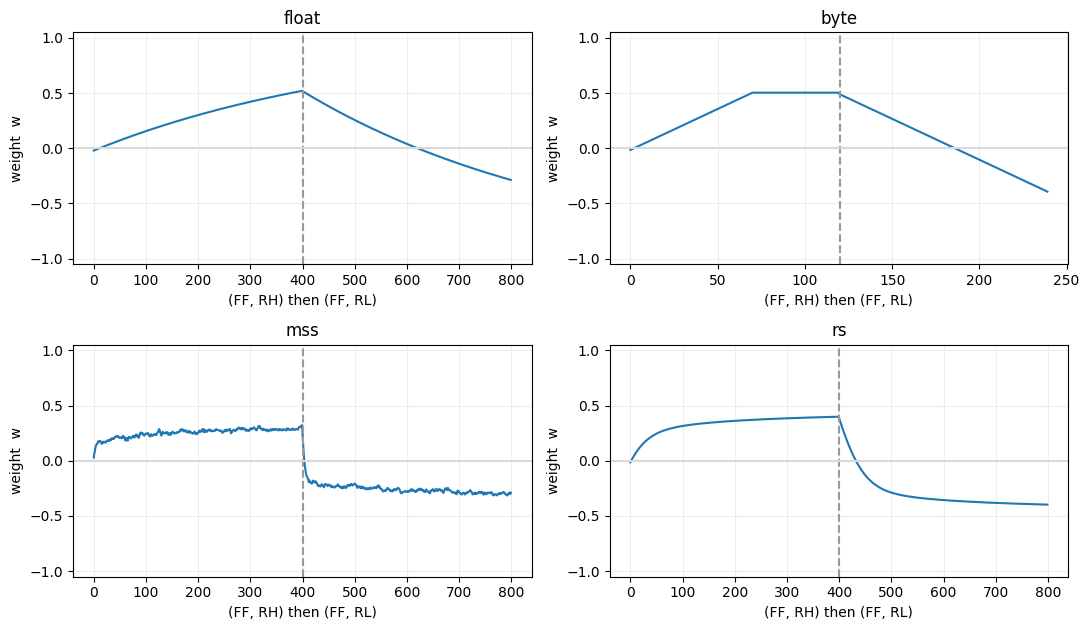

In [10]:
def pulse_up_down(model, n, init='medium', seed=1):
    core = single_synapse_core(model, init, seed)
    up = execute_n(core, 'FF', 'RH', n)        # ramp up
    dn = execute_n(core, 'FF', 'RL', n)        # then ramp down
    gas, gbs = up[0] + dn[0], up[1] + dn[1]
    return w_of(gas, gbs)

panels = [('float', 400), ('byte', 120), ('mss', 400), ('rs', 400)]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))
for ax, (model, n) in zip(axes.flat, panels):
    w = pulse_up_down(model, n)
    ax.plot(w); ax.axvline(n, color='0.6', ls='--'); ax.axhline(0, color='0.85')
    ax.set_ylim(-1.05, 1.05); ax.set_title(model)
    ax.set_xlabel('(FF, RH) then (FF, RL)'); ax.set_ylabel('weight  w')
    ax.grid(color='0.93')
plt.tight_layout(); plt.show()

## Reading without disturbing

`FFLV` reads below the device threshold. For Float and Byte the dead-zone makes the
disturbance to the *state* exactly zero — you can interrogate the pair without casting a
vote, as many times as you like.

This sub-threshold read is the *only* non-disturbing one, and it is also the noisy one: the
read voltage is low (`V_app ≈ 0.05`), and the weight-referred noise goes as `1/V_app`, so the
signal shrinks while the hiss does not. Reading at full voltage would be ~20x cleaner, but a
full-voltage read climbs over the threshold and drives the state. **The price paid for not
disturbing the memristor state is paid in measurement uncertainty:** the state holds perfectly
still while each read carries ~0.02 of hiss, and you pull the weight back out by averaging many
of those non-disturbing reads.

state  w: -0.022489 -> -0.022489    m: 0.105836 -> 0.105836   (unchanged)


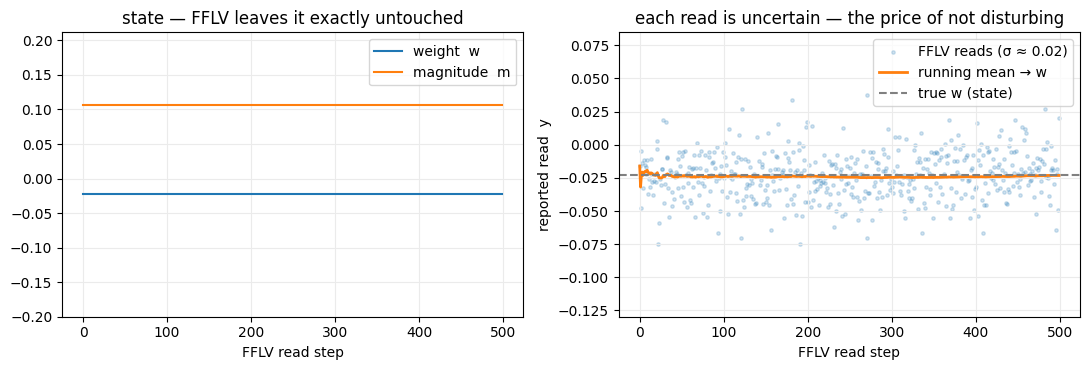

In [11]:
import numpy as np

core = single_synapse_core('float', 'medium', seed=1, read_noise=READ_NOISE)  # noise ON
lane = core.lane(0)
ys, ws, ms = [], [], []
for _ in range(500):
    ys.append(lane.evaluate(Z, 'FFLV'))            # noisy sub-threshold read (returned y)
    ga, gb = core.read_gab(0, Z)                   # the state behind it
    ws.append((ga - gb) / (ga + gb)); ms.append(ga + gb)

run_mean = np.cumsum(ys) / np.arange(1, len(ys) + 1)
print(f'state  w: {ws[0]:+.6f} -> {ws[-1]:+.6f}    m: {ms[0]:.6f} -> {ms[-1]:.6f}   (unchanged)')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(ws, color='tab:blue', label='weight  w')
ax[0].plot(ms, color='tab:orange', label='magnitude  m')
ax[0].set_ylim(-0.2, max(ms) * 2); ax[0].set_xlabel('FFLV read step')
ax[0].set_title('state — FFLV leaves it exactly untouched')
ax[0].legend(); ax[0].grid(color='0.92')

band = 6 * np.std(ys)
ax[1].scatter(range(len(ys)), ys, s=6, alpha=0.2, color='tab:blue', label='FFLV reads (σ ≈ 0.02)')
ax[1].plot(run_mean, color='tab:orange', lw=2, label='running mean → w')
ax[1].axhline(ws[-1], color='0.5', ls='--', label='true w (state)')
ax[1].set_ylim(ws[-1] - band, ws[-1] + band)
ax[1].set_xlabel('FFLV read step'); ax[1].set_ylabel('reported read  y')
ax[1].set_title('each read is uncertain — the price of not disturbing')
ax[1].legend(loc='upper right'); ax[1].grid(color='0.92')
plt.tight_layout(); plt.show()

## The read is a sample

Every read so far came back as a clean number — the exact ratio of two conductances. A real
kT-bit cannot. Each conductance sits at some temperature, and a resistor at temperature `T`
hisses: Johnson–Nyquist noise, the literal `kT` the device is named for. That noise rides on
the **read**, and the emulator models it — ON by default at room temperature.

The readout node sees the pair to the driven rails, so its resistance is `1/m`, and referred to
the weight the read noise is

$$\sigma_w \;=\; \texttt{READ\_NOISE}\,\sqrt{T/T_\text{ref}}\;\frac{V_\text{ref}}{|V_\text{app}|}\;\sqrt{m_\text{ref}/m}.$$

Three knobs, and the one you actually reach for is the **read voltage**. Lower `V_app` and the
noise rises as `1/V_app` — the signal shrinks while the hiss does not — so a sub-threshold read
is the noisy one. `READ_NOISE = 0.02` is the std on a normal sub-threshold read (`FFLV`) at the
reference magnitude; a full-drive `FF` read is ~20x cleaner, but at full voltage it also drives
the devices (the anti-Hebbian disturbance from earlier), so it is a *disturbing* read. The other
two knobs: temperature (`√T`) and — for free — the magnitude (`1/√m`, a confident pair reads
quietly). The cells below sample with `FFLV`, the read you use when the state must not move.

That `1/√m` is the **same** shape the Beta posterior's width carries: a read's spread rises and
falls with the pair's own uncertainty, by the same law. Set the level to the belief and a read
is a draw from the posterior; leave it anywhere sensible and it is still a sample that gets loud
when the pair is unsure and quiets when it is certain. The shape is the gift; the exact width is
the dial — and the dial is the read voltage.

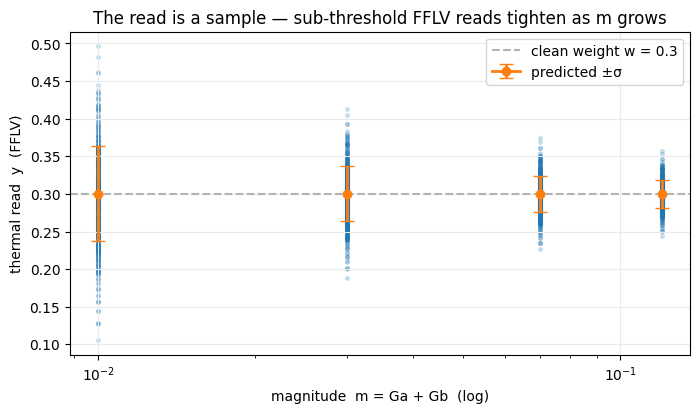

In [12]:
# This section runs standalone — these are also defined in Setup, restated so you can run
# the read-noise cells without re-running the whole notebook from the top.
import numpy as np
import matplotlib.pyplot as plt
from ktram_neural_core import Core, READ_NOISE

Z = (0,)
def single_synapse_core(model='float', init='medium', seed=1, read_noise=0.0, **kw):
    return Core(1, 1, spaces_per_lane=1, num_lanes=1,
                model=model, init=init, seed=seed, read_noise=read_noise, **kw)

GMAX, y0 = 1e-1, 0.3

# READ_NOISE is the read-noise std on a normal sub-threshold read (FFLV, the reference read
# voltage) at m = GMax. It scales as 1/sqrt(m): a confident pair reads quietly.
def sigma_pred(m):
    return READ_NOISE * np.sqrt(GMAX / m)

def read_cloud(level, n=600, seed=1):
    # FFLV is sub-threshold: it leaves the state untouched, so we set the pair ONCE and read it
    # n times. Read the state back — set_start_y clamps Ga at GMax, so the *realized* (w, m) is
    # what we plot against.
    core = single_synapse_core('float', 'medium', seed=seed, read_noise=READ_NOISE)
    core.set_start_y(0, Z, y0=y0, level=level)
    ga, gb = core.read_gab(0, Z)
    w0, m0 = (ga - gb) / (ga + gb), ga + gb
    lane = core.lane(0)
    ys = [lane.evaluate(Z, 'FFLV') for _ in range(n)]
    return np.array(ys), w0, m0

# Holding weight w needs the leading conductance at ~(1+w)/2 * m, and that side rails at GMax, so
# the magnitude that still holds the full weight is capped at m_cap = 2*GMax/(1+w). Stay under it
# so w is genuinely fixed and this figure isolates one thing: the spread shrinking as 1/sqrt(m).
m_cap = 2 * GMAX / (1 + y0)
levels = [0.05, 0.15, 0.35, 0.6]            # realized m = 0.01 .. 0.12, all below m_cap = 0.154

plt.figure(figsize=(8, 4.2))
for level in levels:
    ys, w0, m0 = read_cloud(level)
    plt.scatter(np.full(len(ys), m0), ys, s=7, alpha=0.18, color='tab:blue')
    plt.errorbar(m0, w0, yerr=sigma_pred(m0), color='tab:orange', capsize=5, lw=2, marker='o',
                 zorder=5, label='predicted ±σ' if level == levels[0] else None)
plt.axhline(y0, color='0.7', ls='--', label=f'clean weight w = {y0}')
plt.xscale('log'); plt.xlabel('magnitude  m = Ga + Gb  (log)'); plt.ylabel('thermal read  y  (FFLV)')
plt.title('The read is a sample — sub-threshold FFLV reads tighten as m grows')
plt.legend(); plt.grid(color='0.92'); plt.show()

### A fair coin from the kT

Park the pair at the balance point (`w = 0`) and the clean read is zero — the read is pure
hiss, its sign as likely up as down. Hold down an **unsupervised Hebbian** read from there
(`FF` then `RU`) and the first noisy sample tips the pair; the positive feedback runs with
it to a rail. Reset, run again, and the other rail comes up just as often. A fair coin,
pulled straight from the device's own `kT`, with no random-number generator in the loop —
the bit is whichever sign the thermal read happened to land on.

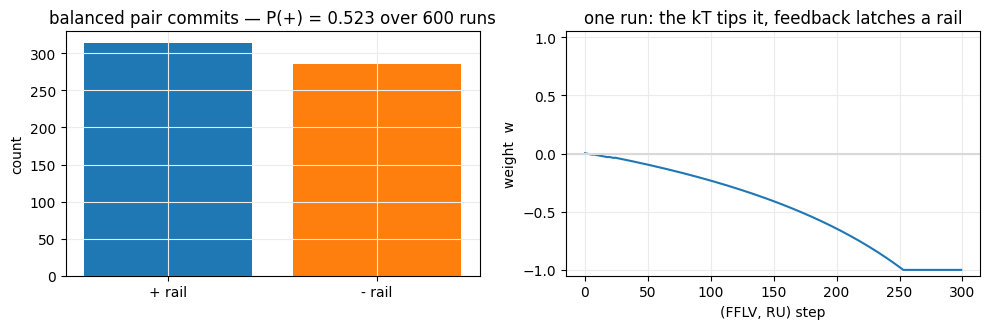

In [13]:
def commit_rail(seed, w0=0.0, n=300, level=0.5):
    # Park the pair at w0, then hold FFLV (non-disturbing) ; RU. The noisy sub-threshold read
    # drives H(y); the unsupervised positive feedback latches whichever rail the early samples pick.
    core = single_synapse_core('float', 'medium', seed=seed, read_noise=READ_NOISE)
    core.set_start_y(0, Z, y0=w0, level=level)
    lane = core.lane(0)
    for _ in range(n):
        lane.evaluate(Z, 'FFLV')
        lane.evaluate(Z, 'RU')
    ga, gb = core.read_gab(0, Z)
    return 1 if ga > gb else 0

runs = 600
bits = [commit_rail(s) for s in range(runs)]
p_plus = sum(bits) / runs

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].bar(['+ rail', '- rail'], [sum(bits), runs - sum(bits)],
          color=['tab:blue', 'tab:orange'])
ax[0].set_title(f'balanced pair commits — P(+) = {p_plus:.3f} over {runs} runs')
ax[0].set_ylabel('count')

# one example trajectory: hiss breaks the tie, feedback runs to a rail
core = single_synapse_core('float', 'medium', seed=3, read_noise=READ_NOISE)
core.set_start_y(0, Z, y0=0.0, level=0.5); lane = core.lane(0); traj = []
for _ in range(300):
    lane.evaluate(Z, 'FFLV'); lane.evaluate(Z, 'RU')
    ga, gb = core.read_gab(0, Z); traj.append((ga - gb) / (ga + gb))
ax[1].plot(traj, color='tab:blue'); ax[1].axhline(0, color='0.85')
ax[1].set_ylim(-1.05, 1.05); ax[1].set_xlabel('(FFLV, RU) step'); ax[1].set_ylabel('weight  w')
ax[1].set_title('one run: the kT tips it, feedback latches a rail')
for a in ax: a.grid(color='0.92')
plt.tight_layout(); plt.show()

### A biased coin you can write

Write a weight to the pair before you sample, and the hiss has to overcome a head start. The
sign of a single thermal read is then a **biased** bit, and the bias is the weight you stored:

$$P(+) \;=\; \Phi\!\big(w / \sigma(m)\big),$$

the Gaussian CDF of the weight measured in units of the read noise. Write `w`, read once, and
you have drawn a random bit whose probability you set — a writable coin. (Hold the Hebbian read
down and that same sample latches to a rail, exactly as the fair coin did.)

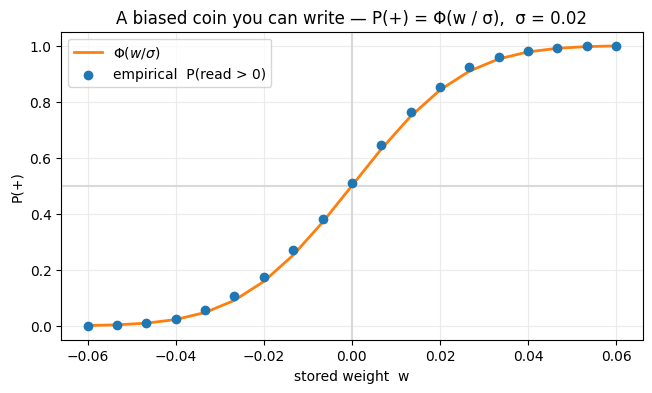

In [14]:
from math import erf
def Phi(x): return 0.5 * (1 + erf(x / np.sqrt(2)))   # standard-normal CDF

def read_bit(seed, w0, level=0.5):
    # Write a weight w0 (m = GMax at level 0.5), then take ONE sub-threshold FFLV read; its sign
    # is the bit.
    core = single_synapse_core('float', 'medium', seed=seed, read_noise=READ_NOISE)
    core.set_start_y(0, Z, y0=w0, level=level)
    return 1 if core.lane(0).evaluate(Z, 'FFLV') > 0 else 0

sigma = READ_NOISE                       # FFLV read at m = GMax: σ_w = READ_NOISE
w0s = np.linspace(-0.06, 0.06, 19)
emp = [np.mean([read_bit(s, w0) for s in range(1500)]) for w0 in w0s]

plt.figure(figsize=(7.5, 4))
plt.plot(w0s, [Phi(w / sigma) for w in w0s], color='tab:orange', lw=2,
         label=r'$\Phi(w/\sigma)$')
plt.scatter(w0s, emp, color='tab:blue', zorder=5, label='empirical  P(read > 0)')
plt.axhline(0.5, color='0.85'); plt.axvline(0, color='0.85')
plt.xlabel('stored weight  w'); plt.ylabel('P(+)')
plt.title(f'A biased coin you can write — P(+) = Φ(w / σ),  σ = {sigma:.2f}')
plt.legend(); plt.grid(color='0.92'); plt.show()

### Dialing the noise: the read voltage

The bias has two controls. The **stored weight** `w` sets where the coin centers — that was the
plot above. A second knob sets how *sharp* it is: the **read voltage**, exposed on the read call
as one normalized number, `evaluate(aat, instr, noise=t)`. `t = 0` reads at the core's voltage
(least noise — the baseline); `t → 1` drops the read voltage toward zero (most noise, `σ ~
1/V_app`). Lower voltage is also less power and less disturbance, so a noisy read stays
non-disturbing — read noisy to *sample*, then feed back to *adapt*. Crank `t` up and even a
strongly weighted pair reads a fair coin; back off and the stored weight takes over. Same pair,
same stored weights, three noise levels.

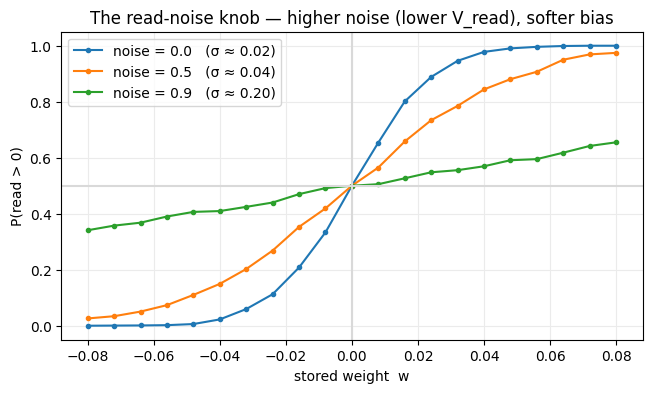

In [15]:
def bias_curve(noise, w0s, n=2000, seed=1):
    # `noise` in [0,1] is the per-read knob: evaluate(..., noise=t) scales the read voltage down,
    # so higher noise = noisier (softer) bias. FFLV stays non-disturbing, so set the weight once
    # per w0 and read it n times.
    core = single_synapse_core('float', 'medium', seed=seed, read_noise=READ_NOISE)
    lane = core.lane(0)
    out = []
    for w0 in w0s:
        core.set_start_y(0, Z, y0=w0, level=0.5)
        out.append(sum(1 if lane.evaluate(Z, 'FFLV', noise=noise) > 0 else 0 for _ in range(n)) / n)
    return out

w0s = np.linspace(-0.08, 0.08, 21)
plt.figure(figsize=(7.5, 4))
for noise in (0.0, 0.5, 0.9):
    sig = READ_NOISE / max(1e-3, 1 - noise)     # σ at m = GMax for this noise level
    plt.plot(w0s, bias_curve(noise, w0s), marker='o', ms=3,
             label=f'noise = {noise:.1f}   (σ ≈ {sig:.2f})')
plt.axhline(0.5, color='0.85'); plt.axvline(0, color='0.85')
plt.xlabel('stored weight  w'); plt.ylabel('P(read > 0)')
plt.title('The read-noise knob — higher noise (lower V_read), softer bias')
plt.legend(); plt.grid(color='0.92'); plt.show()

### Adaptive and generative: a writable random source

Both halves of the kT-bit at once. **Generative:** read a pair through the noise knob and the
sign is a random bit, biased by the stored weight — `P(+) = Φ(w/σ)`. **Adaptive:** that weight
is not fixed; the feedback instructions write it, so the bias is *writable* and re-writable on
the fly. Below, the same pair is given three weights in turn (top), and the bitstream it
generates tracks each one (bottom) — a random-number source whose bias you program into the
device. The reads are sub-threshold, so sampling never erodes the weight it is sampling: you can
read it as a generator and still drive it as a synapse. That is the pattern — a noisy
sub-threshold read to sample, a feedback to adapt — and the threshold is what keeps the two from
colliding.

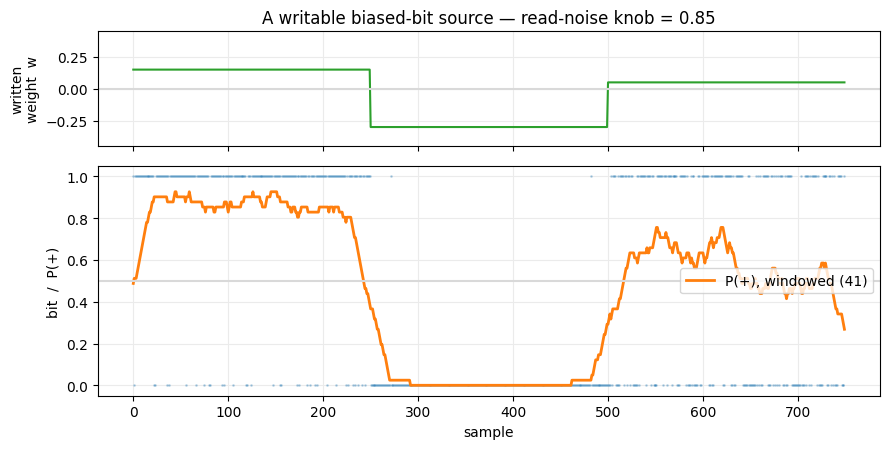

In [16]:
# A *writable* biased-bit source: write a weight (the bias), then read it through the noise knob
# to draw bits. Adaptive (the stored weight — set here directly; the feedback instructions write
# it the same way) + generative (the sampled bits). Re-write the weight and the bias follows.
core = single_synapse_core('float', 'medium', seed=1, read_noise=READ_NOISE)
lane = core.lane(0)
NOISE = 0.85                                          # read-noise knob (σ = READ_NOISE/(1-NOISE))
phases = [(0.15, 250), (-0.30, 250), (0.05, 250)]    # (written weight, how many bits)

bits, w_line = [], []
for weight, count in phases:
    core.set_start_y(0, Z, y0=weight, level=0.5)      # write the weight
    for _ in range(count):
        bits.append(1 if lane.evaluate(Z, 'FFLV', noise=NOISE) > 0 else 0)
        w_line.append(weight)
bits, w_line = np.array(bits), np.array(w_line)
win = 41
p_win = np.convolve(bits, np.ones(win) / win, mode='same')   # windowed P(+)

fig, ax = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True,
                       gridspec_kw={'height_ratios': [1, 2]})
ax[0].plot(w_line, color='tab:green'); ax[0].axhline(0, color='0.85')
ax[0].set_ylim(-0.45, 0.45); ax[0].set_ylabel('written\nweight  w')
ax[0].set_title(f'A writable biased-bit source — read-noise knob = {NOISE}')
ax[1].plot(bits, '.', ms=2, alpha=0.25, color='tab:blue')
ax[1].plot(p_win, color='tab:orange', lw=2, label=f'P(+), windowed ({win})')
ax[1].axhline(0.5, color='0.85'); ax[1].set_ylim(-0.05, 1.05)
ax[1].set_xlabel('sample'); ax[1].set_ylabel('bit  /  P(+)'); ax[1].legend(loc='center right')
for a in ax: a.grid(color='0.92')
plt.tight_layout(); plt.show()

### Many pairs read quieter — the lane pools evidence

A lane reads several pairs through one 2-1 divider, so the readout node's resistance is
`1/Σm` — the noise scales with the **total** magnitude, `σ² ∝ kT/Σᵢmᵢ`, not per pair. Put
`N` equally-confident pairs in a lane and the read noise falls as `1/√N`: pooling evidence
is pooling precision. It is the same inverse-variance weighting the clean lane output
`y = Σᵢ mᵢwᵢ / Σᵢ mᵢ` performs — the wire does it for free.

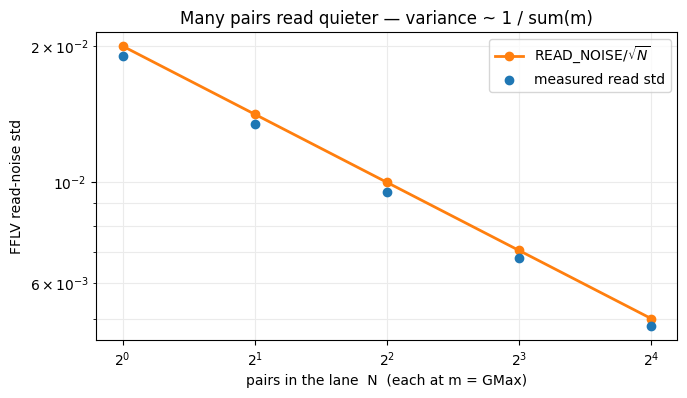

In [17]:
def lane_read_std(n_pairs, n=600, level=0.5, y0=0.0, seed=1):
    # A lane of n_pairs spaces, all selected (AAT = (0,)*n_pairs), each pinned to m = GMax. FFLV is
    # non-disturbing, so set once and read n times; the 2-1 readout sums the pairs, so the noise
    # sees the total magnitude sum(m_i) = n_pairs*GMax.
    core = Core(1, 1, spaces_per_lane=n_pairs, num_lanes=1,
                model='float', init='medium', seed=seed, read_noise=READ_NOISE)
    aat = (0,) * n_pairs
    core.set_start_y(0, aat, y0=y0, level=level)
    lane = core.lane(0)
    return np.std([lane.evaluate(aat, 'FFLV') for _ in range(n)])

counts = [1, 2, 4, 8, 16]
stds = [lane_read_std(k) for k in counts]
pred = [READ_NOISE / np.sqrt(k) for k in counts]   # equal pairs: σ = READ_NOISE/√N

plt.figure(figsize=(7.5, 4))
plt.plot(counts, pred, color='tab:orange', lw=2, marker='o',
         label=r'$\mathrm{READ\_NOISE}/\sqrt{N}$')
plt.scatter(counts, stds, color='tab:blue', zorder=5, label='measured read std')
plt.xscale('log', base=2); plt.yscale('log')
plt.xlabel('pairs in the lane  N  (each at m = GMax)'); plt.ylabel('FFLV read-noise std')
plt.title('Many pairs read quieter — variance ~ 1 / sum(m)')
plt.legend(); plt.grid(color='0.92', which='both'); plt.show()

## Where this goes

These single-pair dynamics — the inertia, the wash-out, the commit, the soft rail — are
the AHaH attractors the classification chapters build on. Swap `init`, `seed`, the step counts, or the instruction strings in any cell above
and watch the two numbers — the weight `w` and the magnitude `m` — move.